In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import requests
import io

# Step 1: Load the data from the provided Google Drive URL and handle discrepancies
print("Step 1: Loading and Cleaning Data")
try:
    # Google Drive shareable link format
    # The file ID is extracted from the URL
    file_id = '1tWiVIuZWeRxxQ4xDee5mAzaCC4zOnctf'
    url = f'https://drive.google.com/uc?export=download&id={file_id}'

    # Download the file content
    response = requests.get(url)
    response.raise_for_status()  # Raise an exception for bad status codes

    # Use io.StringIO to read the content directly into pandas
    df = pd.read_csv(io.StringIO(response.text))
    print("File loaded successfully from Google Drive.")

except requests.exceptions.RequestException as e:
    print(f"Error downloading the file from Google Drive: {e}")
    exit()

Step 1: Loading and Cleaning Data
File loaded successfully from Google Drive.


In [2]:
# Step 2: Initial data inspection and handling of data quality issues
print("\nInitial data inspection:")
print(df.head())
print(df.info())

# Coerce non-numeric values to NaN for cleaning and drop rows
print("\nCleaning data by converting non-numeric values to NaN and dropping rows...")
for col in ['Price']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing SalePrice values with the mean, as per the original script
if 'Price' in df.columns:
    df['Price'] = df['Price'].fillna(df['Price'].mean())

df_cleaned = df.dropna().copy()
print("\nChecking for null values after cleaning:")
print(df_cleaned.isnull().sum())
print(f"Original shape: {df.shape}, Cleaned shape: {df_cleaned.shape}")

# Drop the 'Id' column as it's not needed for the model
if 'Id' in df_cleaned.columns:
    df_cleaned.drop(['Id'], axis=1, inplace=True)
    print("Dropped 'Id' column.")


Initial data inspection:
      Size  NumberOfRooms  PropertyAge          Price  Location Amenities
0  2185.43              5           53  114912.100766     Rural       Gym
1  4778.21              1           34  797303.895802    Suburb    Garden
2  3793.97              4           36  334736.933855  Downtown       Gym
3  3193.96              3           39  464215.534445     Rural       Gym
4  1202.08              5           51  462880.499923  Downtown       Gym
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Size           40000 non-null  float64
 1   NumberOfRooms  40000 non-null  int64  
 2   PropertyAge    40000 non-null  int64  
 3   Price          40000 non-null  float64
 4   Location       40000 non-null  object 
 5   Amenities      30059 non-null  object 
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB
None

Cl


Step 2: Variable Categorization and Visualization

Categorical variables: 2
['Location', 'Amenities']

Numerical variables:
['Size', 'NumberOfRooms', 'PropertyAge', 'Price']


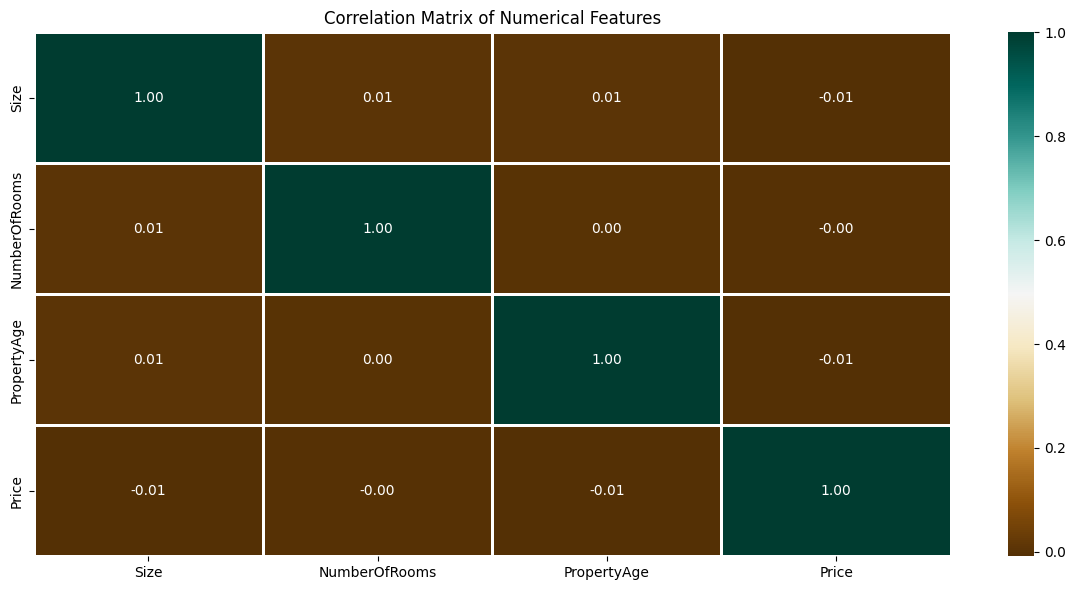

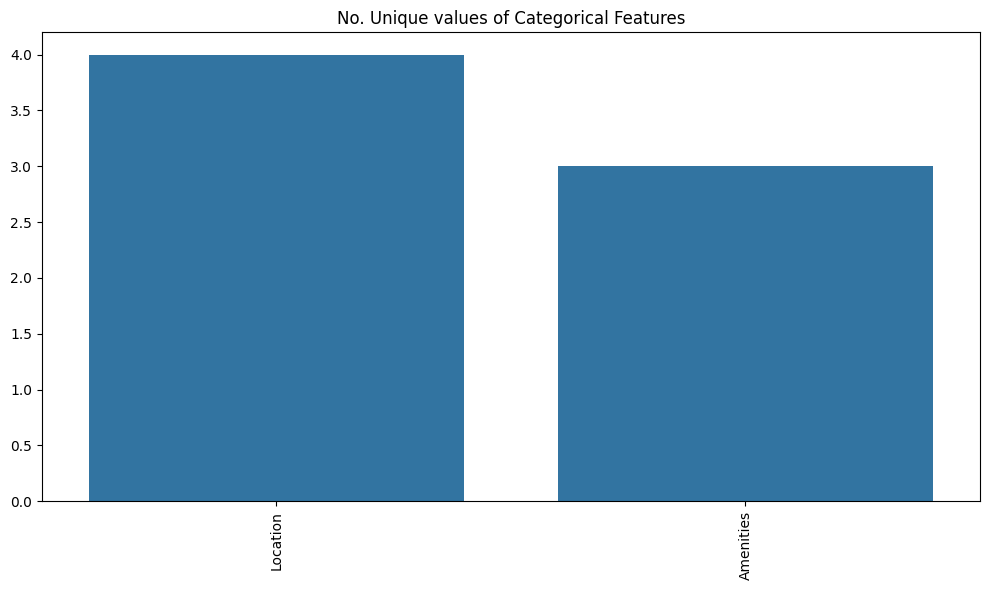

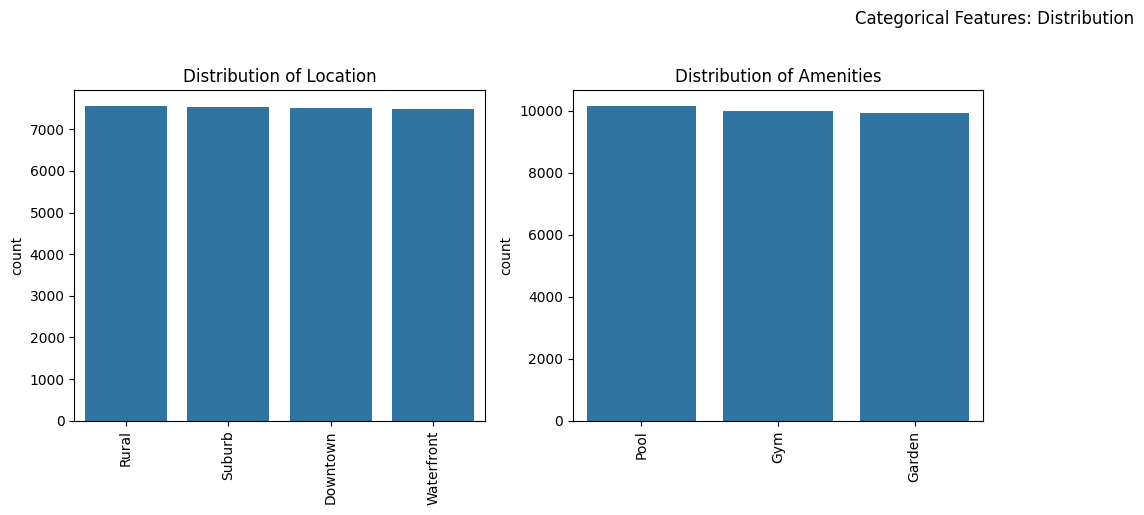

In [3]:
# Step 3: Categorize variables
print("\nStep 2: Variable Categorization and Visualization")
obj = (df_cleaned.dtypes == 'object')
object_cols = list(obj[obj].index)
print("\nCategorical variables:", len(object_cols))
print(object_cols)

numerical_dataset = df_cleaned.select_dtypes(include=['number'])
numerical_cols = numerical_dataset.columns.tolist()
print("\nNumerical variables:")
print(numerical_cols)

# Visualize the data
# Heatmap for numerical correlation
plt.figure(figsize=(12, 6))
if not numerical_dataset.empty:
    sns.heatmap(numerical_dataset.corr(), cmap='BrBG', fmt='.2f', linewidths=2, annot=True)
    plt.title('Correlation Matrix of Numerical Features')
    plt.tight_layout()
    plt.show()

# Bar plot of unique values of categorical features
if object_cols:
    unique_values = [df_cleaned[col].unique().size for col in object_cols]
    plt.figure(figsize=(10, 6))
    plt.title('No. Unique values of Categorical Features')
    plt.xticks(rotation=90)
    sns.barplot(x=object_cols, y=unique_values)
    plt.tight_layout()
    plt.show()

# Distribution of categorical features
if object_cols:
    num_cols = len(object_cols)
    rows = int(num_cols / 4) + 1
    cols = 4
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    fig.suptitle('Categorical Features: Distribution', y=1.02)

    # Flatten axes for easy iteration
    axes = axes.flatten()

    for i, col in enumerate(object_cols):
        y = df_cleaned[col].value_counts()
        sns.barplot(x=list(y.index), y=y, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].tick_params(axis='x', rotation=90)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [4]:
# Step 4: Preprocess data for machine learning
print("\nStep 3: Data Preprocessing")
# One-Hot Encoding
OH_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
OH_cols = pd.DataFrame(OH_encoder.fit_transform(df_cleaned[object_cols]))
OH_cols.index = df_cleaned.index
OH_cols.columns = OH_encoder.get_feature_names_out()
df_final = df_cleaned.drop(object_cols, axis=1)
df_final = pd.concat([df_final, OH_cols], axis=1)
print("\nFinal DataFrame after one-hot encoding:")
print(df_final.head())
print(df_final.info())

# Split the data
X = df_final.drop(['Price'], axis=1)
Y = df_final['Price']
X_train, X_valid, Y_train, Y_valid = train_test_split(X, Y, train_size=0.95, test_size=0.05, random_state=0)
print(f"\nTraining data shape: {X_train.shape}, {Y_train.shape}")
print(f"Validation data shape: {X_valid.shape}, {Y_valid.shape}")


Step 3: Data Preprocessing

Final DataFrame after one-hot encoding:
      Size  NumberOfRooms  PropertyAge          Price  Location_Downtown  \
0  2185.43              5           53  114912.100766                0.0   
1  4778.21              1           34  797303.895802                0.0   
2  3793.97              4           36  334736.933855                1.0   
3  3193.96              3           39  464215.534445                0.0   
4  1202.08              5           51  462880.499923                1.0   

   Location_Rural  Location_Suburb  Location_Waterfront  Amenities_Garden  \
0             1.0              0.0                  0.0               0.0   
1             0.0              1.0                  0.0               1.0   
2             0.0              0.0                  0.0               0.0   
3             1.0              0.0                  0.0               0.0   
4             0.0              0.0                  0.0               0.0   

   Amenitie

In [5]:
# Step 5: Build and evaluate machine learning models
print("\nStep 4: Model Training and Evaluation")
# Model 1: Support Vector Regression (SVR)
print("\n--- Model: Support Vector Regression (SVR) ---")
model_SVR = svm.SVR()
model_SVR.fit(X_train, Y_train)
Y_pred_SVR = model_SVR.predict(X_valid)
mape_SVR = mean_absolute_percentage_error(Y_valid, Y_pred_SVR)
print(f"Mean Absolute Percentage Error (MAPE) for SVR: {mape_SVR:.4f}")

# Model 2: Random Forest Regressor (RFR)
print("\n--- Model: Random Forest Regressor (RFR) ---")
model_RFR = RandomForestRegressor(n_estimators=10)
model_RFR.fit(X_train, Y_train)
Y_pred_RFR = model_RFR.predict(X_valid)
mape_RFR = mean_absolute_percentage_error(Y_valid, Y_pred_RFR)
print(f"Mean Absolute Percentage Error (MAPE) for RFR: {mape_RFR:.4f}")

# Model 3: Linear Regression (LR)
print("\n--- Model: Linear Regression (LR) ---")
model_LR = LinearRegression()
model_LR.fit(X_train, Y_train)
Y_pred_LR = model_LR.predict(X_valid)
mape_LR = mean_absolute_percentage_error(Y_valid, Y_pred_LR)
print(f"Mean Absolute Percentage Error (MAPE) for LR: {mape_LR:.4f}")


Step 4: Model Training and Evaluation

--- Model: Support Vector Regression (SVR) ---
Mean Absolute Percentage Error (MAPE) for SVR: 0.7942

--- Model: Random Forest Regressor (RFR) ---
Mean Absolute Percentage Error (MAPE) for RFR: 0.7265

--- Model: Linear Regression (LR) ---
Mean Absolute Percentage Error (MAPE) for LR: 0.7110
